In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "department": ["Engineering", "Sales", "HR", "Marketing",
                    "Engineering", "Sales", "HR", "Engineering"],
    "salary": [85000, 62000, 58000, 65000,
               91000, 59000, 60000, 88000]
}

df = pd.DataFrame(data)

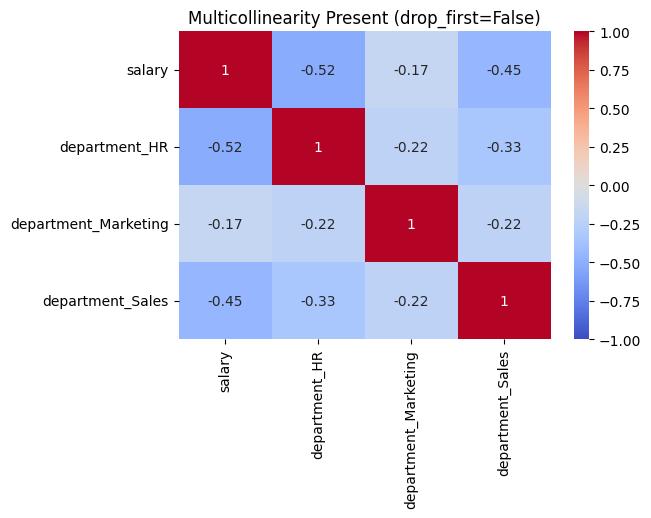

In [12]:
def encode_categorical(df: pd.DataFrame, column: str, drop_first: bool=True) -> pd.DataFrame:
    return pd.get_dummies(df, prefix=column, drop_first=drop_first)

dummies_true = encode_categorical(df, column="department", drop_first=True)
# drop first = False, means there will be a extra column be made for each unique category, but we dont need it because if in 3 categories if 2 categories says false, then obviously the 3rd column will be 

corr_false = dummies_true.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_false, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Multicollinearity Present (drop_first=False)")
plt.show()

drop_first=False:
    salary  department_Engineering  department_HR  department_Marketing  \
0   85000                    True          False                 False   
1   62000                   False          False                 False   
2   58000                   False           True                 False   
3   65000                   False          False                  True   
4   91000                    True          False                 False   
5   59000                   False          False                 False   
6   60000                   False           True                 False   
7   88000                    True          False                 False   

   department_Sales  
0             False  
1              True  
2             False  
3             False  
4             False  
5              True  
6             False  
7             False   



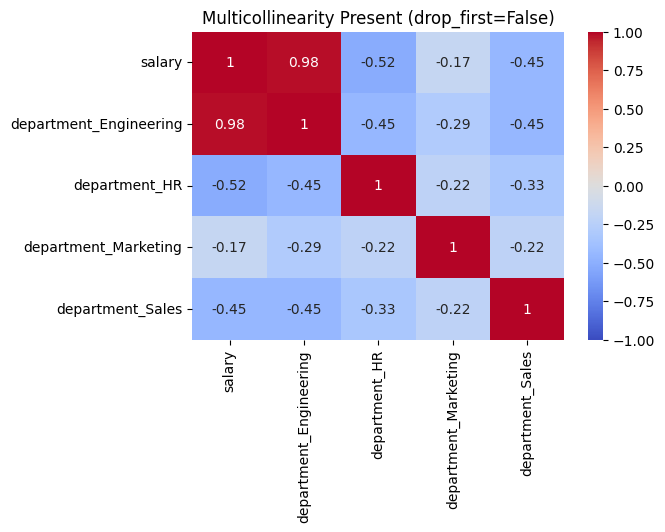

drop_first=True:
    salary  department_HR  department_Marketing  department_Sales
0   85000          False                 False             False
1   62000          False                 False              True
2   58000           True                 False             False
3   65000          False                  True             False
4   91000          False                 False             False
5   59000          False                 False              True
6   60000           True                 False             False
7   88000          False                 False             False 



In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "department": ["Engineering", "Sales", "HR", "Marketing",
                    "Engineering", "Sales", "HR", "Engineering"],
    "salary": [85000, 62000, 58000, 65000,
               91000, 59000, 60000, 88000]
}

df = pd.DataFrame(data)


def encode_categorical(df: pd.DataFrame, column: str, drop_first: bool = True) -> pd.DataFrame:
    return pd.get_dummies(df, prefix=column, drop_first=drop_first)


# --- Run 1: drop_first=False (trap present) ---
dummies_false = encode_categorical(df, column="department", drop_first=False)
print("drop_first=False:\n", dummies_false, "\n")

# Why this breaks a linear model:
# With all 4 dummy columns present, department_Marketing is an EXACT linear
# combination of the other three: Marketing = 1 - (Engineering + HR + Sales).
# This makes the design matrix X singular (not full rank) once the intercept
# is added. Linear regression solves for coefficients via (X^T X)^-1, and a
# singular matrix has no unique inverse -- so the solver either fails outright
# or arbitrarily/unstably splits the coefficient weight among the correlated
# dummy columns. It's not just "redundant info" -- it literally breaks the
# matrix inversion step the algorithm depends on.

corr_false = dummies_false.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_false, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title("Multicollinearity Present (drop_first=False)")
plt.show()

# --- Run 2: drop_first=True (trap avoided) ---
dummies_true = encode_categorical(df, column="department", drop_first=True)
print("drop_first=True:\n", dummies_true, "\n")
# Marketing is dropped as the baseline category. Its effect is absorbed into
# the intercept -- the other 3 dummies now represent "difference from Marketing."
# No exact linear combination exists among the remaining columns, so X is full

# rank and (X^T X)^-1 is well-defined.

In [17]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge, Lasso

X, y = make_regression(n_samples=100, n_features=10, n_informative=4, noise=15, random_state=42)

def compare_regularization(X: np.ndarray, y: np.ndarray, alphas: list[float]) -> pd.DataFrame:
    results = []
    for al in alphas:
        ridge = Ridge(alpha=al)
        ridge.fit(X, y)
        rid_non_zero = np.sum(np.abs(ridge.coef_) > 1e-4)

        lasso = Lasso(alpha=al)
        lasso.fit(X, y)
        las_non_zero = np.sum(np.abs(lasso.coef_) > 1e-4)

        results.append({
            "Alpha": al,
            "Model": "Ridge",
            "Non_Zero_Coeffs": rid_non_zero,
            "R2_Score": ridge.score(X, y)
        })
        results.append({
            "Alpha": al,
            "Model": "Lasso",
            "Non_Zero_Coeffs": las_non_zero,
            "R2_Score": lasso.score(X, y)
        })

    return pd.DataFrame(results)

compare_regularization(X, y, alphas=[0.01, 1, 10, 100])

,Alpha,Model,Non_Zero_Coeffs,R2_Score
0,0.01,Ridge,10,0.980183
1,0.01,Lasso,10,0.980183
2,1.00,Ridge,10,0.980092
3,1.00,Lasso,6,0.979472
4,10.00,Ridge,10,0.972633
5,10.00,Lasso,3,0.940394
6,100.00,Ridge,10,0.753360
7,100.00,Lasso,0,0.000000
